# What makes a city healthy? A machine learning analysis of European cities
## Part 2: Data cleaning, exploration and modelling


This notebook analyses premature mortality — deaths under 65 per 100,000 population — 
across 502 European cities using environmental, socioeconomic and demographic indicators. 
The central question is: **which city-level characteristics are most strongly associated 
with premature mortality, and what does this imply for urban health policy?**

The analysis is relevant to two audiences: national governments seeking to understand 
which behavioral and structural factors drive mortality differences between countries, 
and city administrations looking for actionable levers within their control — green space, 
air quality, economic development, education.

We use linear regression for interpretable effect sizes and random forest with SHAP 
values for non-linear importance estimation. A particular focus is placed on whether 
environmental noise exposure adds predictive value beyond socioeconomic variables, 
given its established role in the epidemiological literature but limited data coverage 
across European cities.

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm  
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler       
            
from statsmodels.stats.outliers_influence import variance_inflation_factor  
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LassoCV   
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor 

import shap                                             
import warnings
import geopandas as gpd

## 1. Loading data prepared with data_loader, sourced from Eurostat, END and ISglobal publications

In [2]:
# 1.1 Loading dataframe

df = pd.read_excel("DATA/OUTPUT/master_2015_2019.xlsx")

In [3]:
df.sample(5)

,City_code,city,Country,NUTS2,NUTS3,deaths_under65_rate,road_deaths_per10k,pop_total,old_age_dependency,cars_per1000,...,total_lden_pct_55,pm25_median,no2_median,ga_pct_mean,obesity_pct,smoking_pct,unmet_medical_pct,gdp_pps,pop_density,doctors_per100k
332,IT010C,Catania (greater city),IT,ITG1,ITG17,168.601390,0.5400,309330.75,34.900000,716.3100,...,69.44,16.157970,23.342990,30.432943,8.80,25,2.875,18525.0,311.625,435.674132
250,FR012C,Grenoble (greater city),FR,FRK2,FRK24,133.433754,0.1975,364573.25,29.950000,474.0900,...,101.92,12.847290,18.055490,42.428963,15.05,36,1.175,30400.0,161.650,342.926286
374,IT054C,Bitonto,IT,ITF4,ITF47,126.158337,0.4175,54720.50,27.633333,521.5550,...,NaN,13.760100,16.606980,63.444702,8.80,25,2.875,21775.0,324.750,376.843291
346,IT024C,Reggio di Calabria,IT,ITF6,ITF65,152.137023,0.3475,180833.00,35.233333,626.0775,...,NaN,13.556090,16.412245,56.876266,8.80,25,2.875,17550.0,172.675,389.050463
317,HU014C,Békéscsaba,HU,HU33,HU332,360.669395,0.5850,59552.75,33.533333,365.3650,...,NaN,16.413345,13.600725,43.907822,22.25,27,1.025,12775.0,60.750,342.677657


In [4]:
# 1.2 Verifying if the data is in the right type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   City_code            502 non-null    object 
 1   city                 502 non-null    object 
 2   Country              502 non-null    object 
 3   NUTS2                502 non-null    object 
 4   NUTS3                502 non-null    object 
 5   deaths_under65_rate  502 non-null    float64
 6   road_deaths_per10k   502 non-null    float64
 7   pop_total            502 non-null    float64
 8   old_age_dependency   502 non-null    float64
 9   cars_per1000         502 non-null    float64
 10  employment_rate      502 non-null    float64
 11  tertiary_edu_pct     502 non-null    float64
 12  total_lnight_pct_55  230 non-null    float64
 13  total_lden_pct_55    231 non-null    float64
 14  pm25_median          502 non-null    float64
 15  no2_median           502 non-null    flo

In [5]:
# 1.2 Dataset size
print("Dataset size:", df.shape)

Dataset size: (502, 23)


In [6]:
# 1.3 Descriptive statistics
df.describe().round(1)

,deaths_under65_rate,road_deaths_per10k,pop_total,old_age_dependency,cars_per1000,employment_rate,tertiary_edu_pct,total_lnight_pct_55,total_lden_pct_55,pm25_median,no2_median,ga_pct_mean,obesity_pct,smoking_pct,unmet_medical_pct,gdp_pps,pop_density,doctors_per100k
count,502.0,502.0,502.0,502.0,502.0,502.0,502.0,230.0,231.0,502.0,502.0,502.0,502.0,502.0,502.0,502.0,502.0,502.0
mean,205.3,0.3,259371.7,33.0,490.8,75.0,31.7,19.0,55.5,13.8,20.0,43.5,15.6,27.2,1.4,30247.3,582.0,372.1
std,75.8,0.3,633843.5,6.7,159.8,6.8,9.7,12.6,21.2,3.4,5.9,11.4,3.9,5.3,1.5,15586.3,1212.9,81.9
min,89.9,0.0,40716.2,13.6,220.9,50.2,12.4,0.1,0.5,4.0,4.2,7.1,8.8,7.0,0.2,7625.0,4.9,125.9
25%,149.6,0.2,75962.7,28.3,419.3,72.7,23.6,10.2,39.5,12.2,15.5,35.6,14.7,25.0,0.3,21000.0,98.4,323.6
50%,179.0,0.3,119202.8,32.6,466.5,76.2,31.4,15.4,55.5,13.1,19.6,42.9,15.0,27.0,1.2,27100.0,217.9,376.8
75%,252.2,0.4,210897.9,36.8,541.6,79.0,38.4,24.7,71.0,15.1,23.3,50.2,20.0,29.0,2.9,34556.2,713.9,435.5
max,511.4,2.2,10223467.2,67.4,2763.6,88.3,63.3,71.1,104.8,27.2,39.7,75.4,22.2,36.0,14.8,166075.0,21116.8,807.0


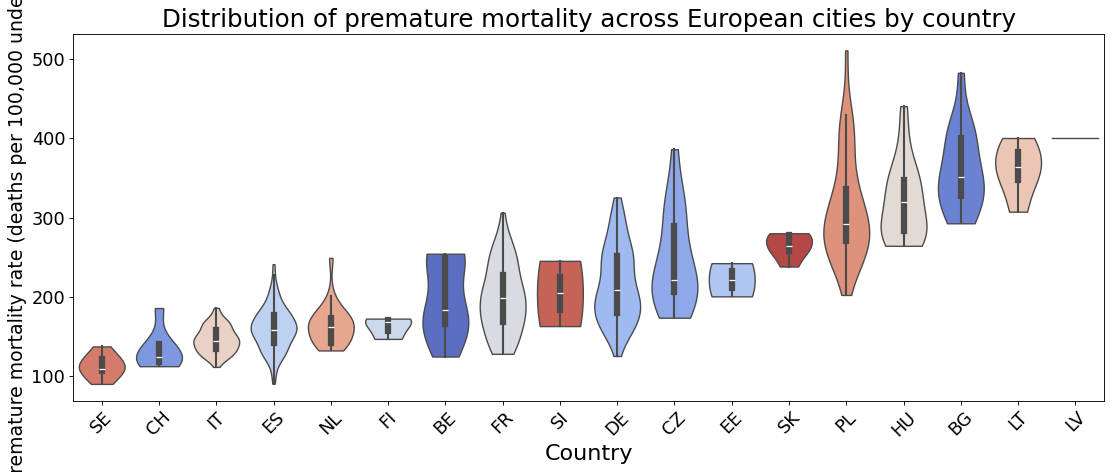

In [10]:
# 1.4 Distribution of premature mortality rates by country
# If all variation were between countries, city-level analysis would not be necessary. The within-country spread visible in the violin 
# plots justifies analysing individual cities rather than country averages.

country_order = df.groupby('Country')['deaths_under65_rate'].median().sort_values().index

plt.figure(figsize=(14, 6), dpi=80) 
sns.violinplot(data=df, x='Country', y='deaths_under65_rate',
               order=country_order, hue='Country', palette='coolwarm',
               legend=False, cut=0)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Country', fontsize=20)
plt.ylabel('Premature mortality rate (deaths per 100,000 under 65)', fontsize=17)
plt.title('Distribution of premature mortality across European cities by country', fontsize=22)
plt.tight_layout()
plt.show()

## 2. Visualization of feature distributions

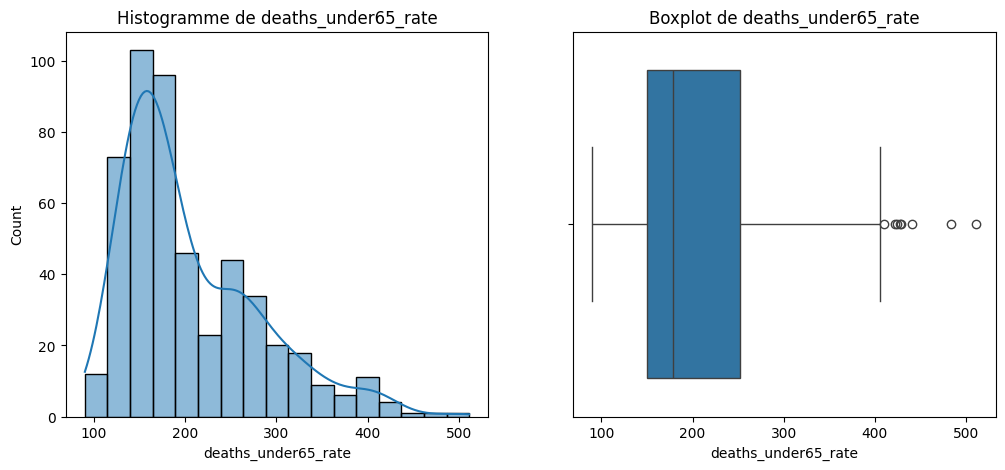

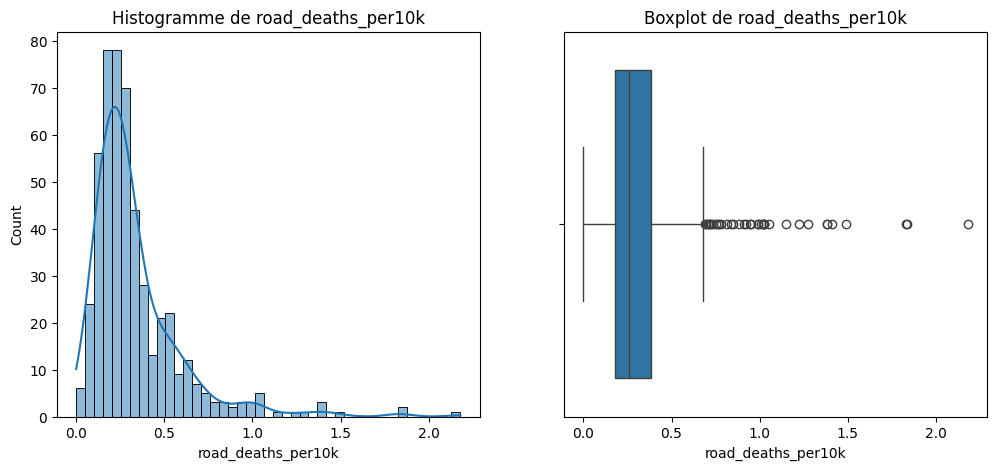

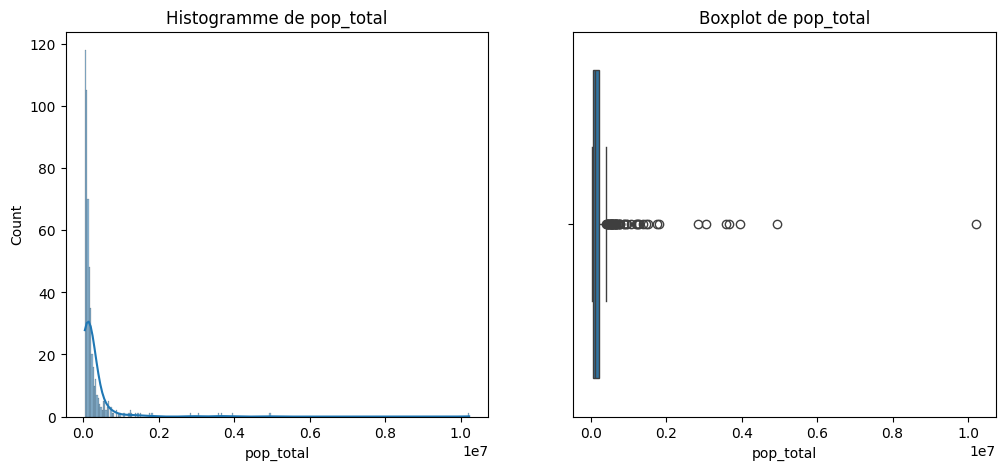

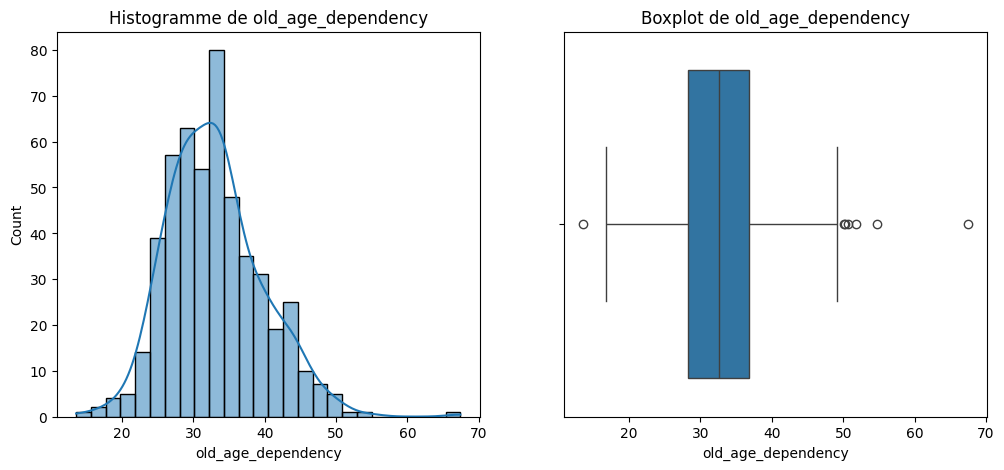

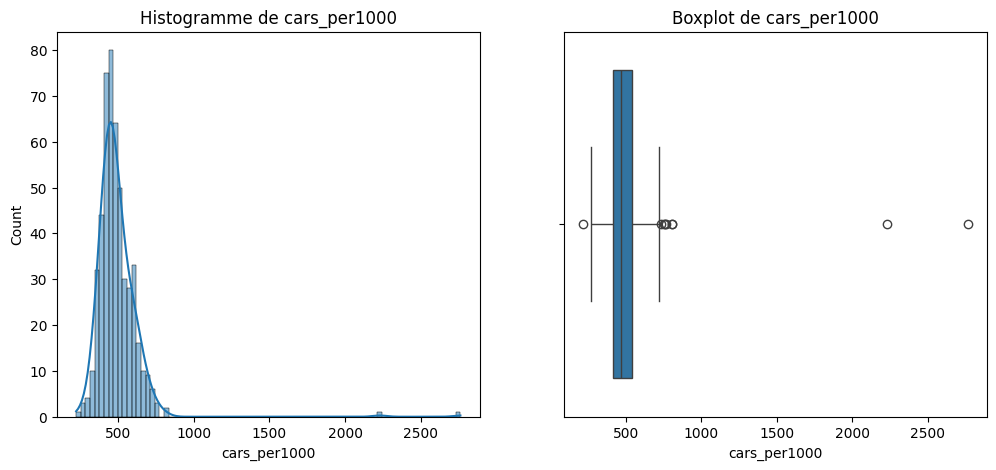

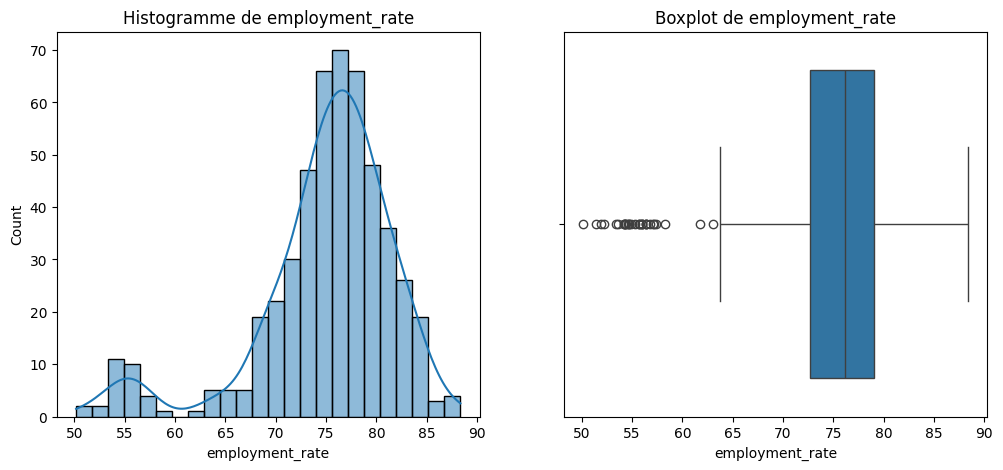

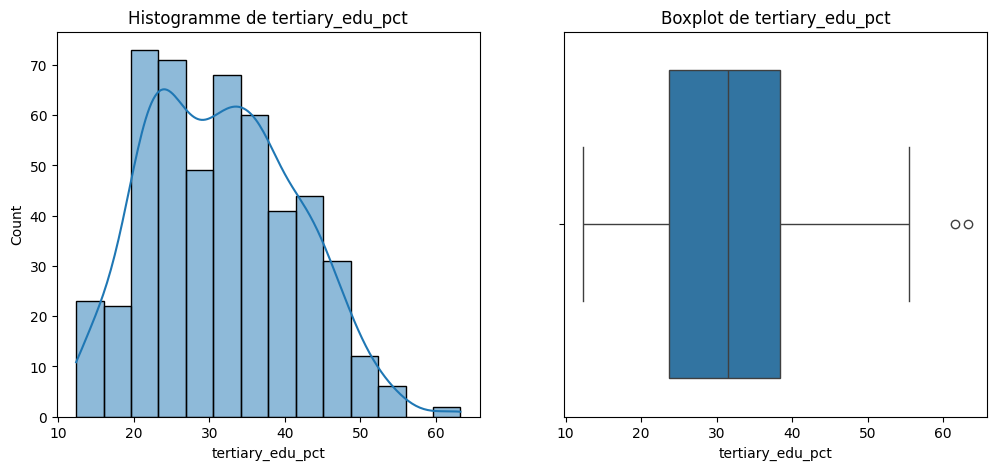

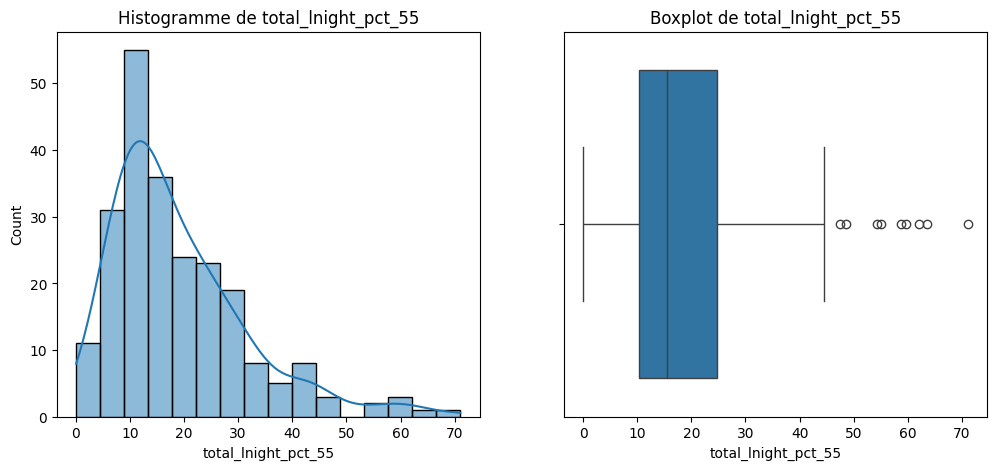

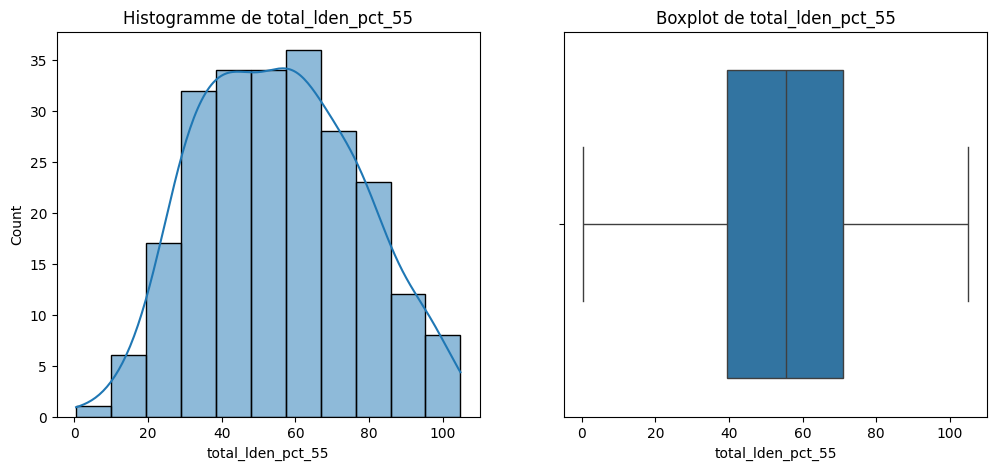

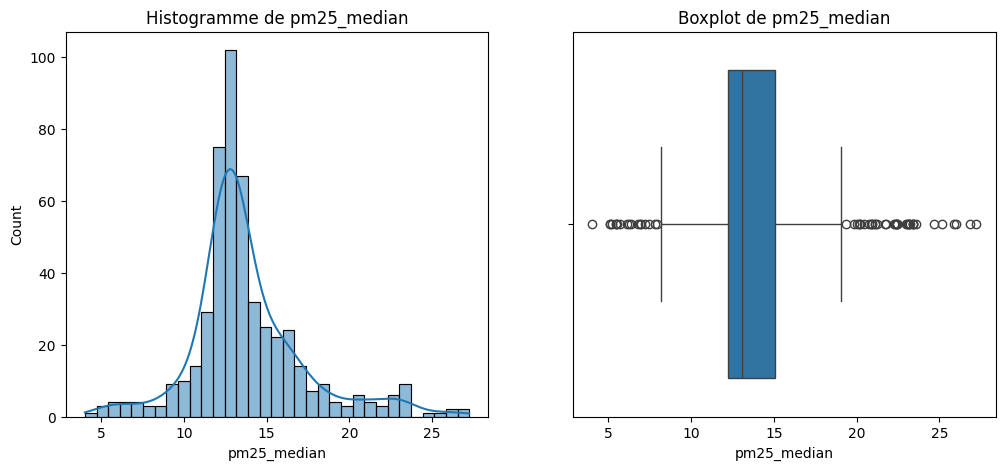

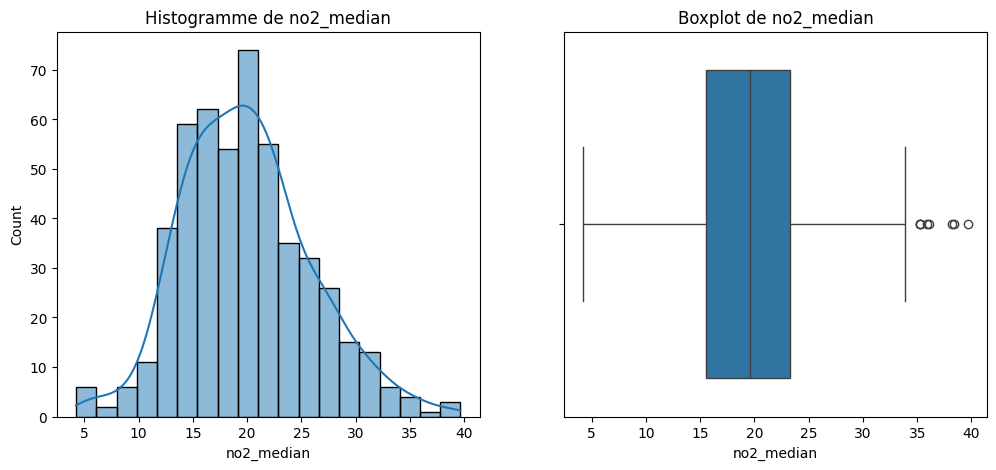

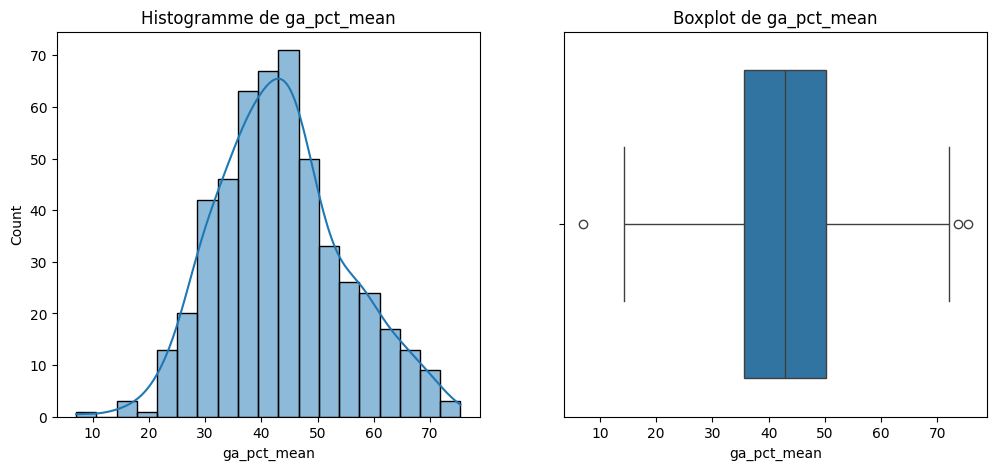

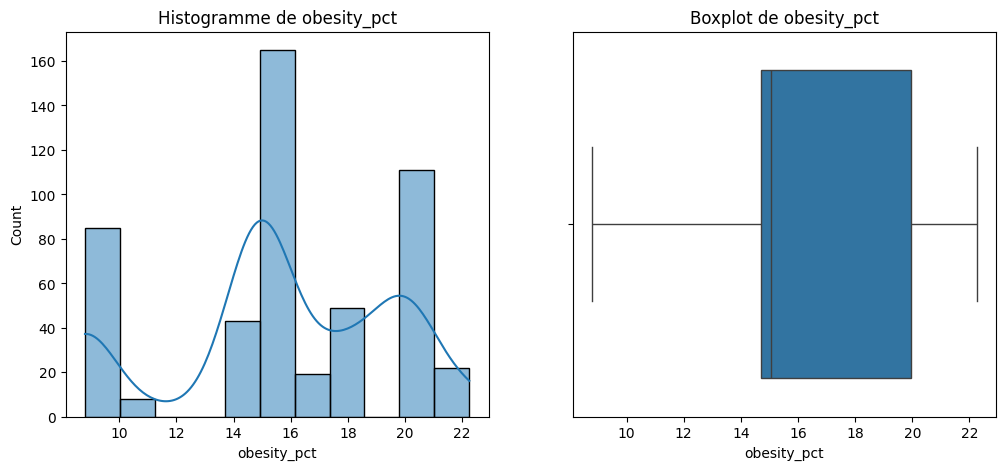

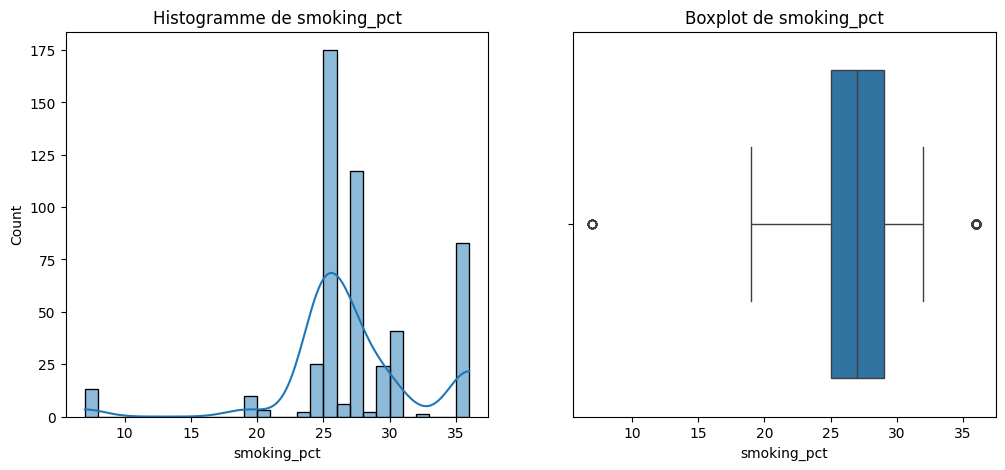

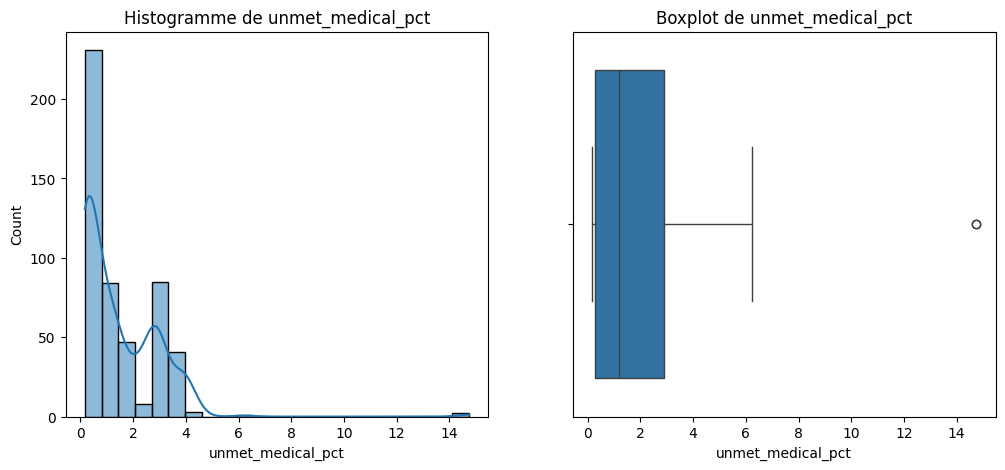

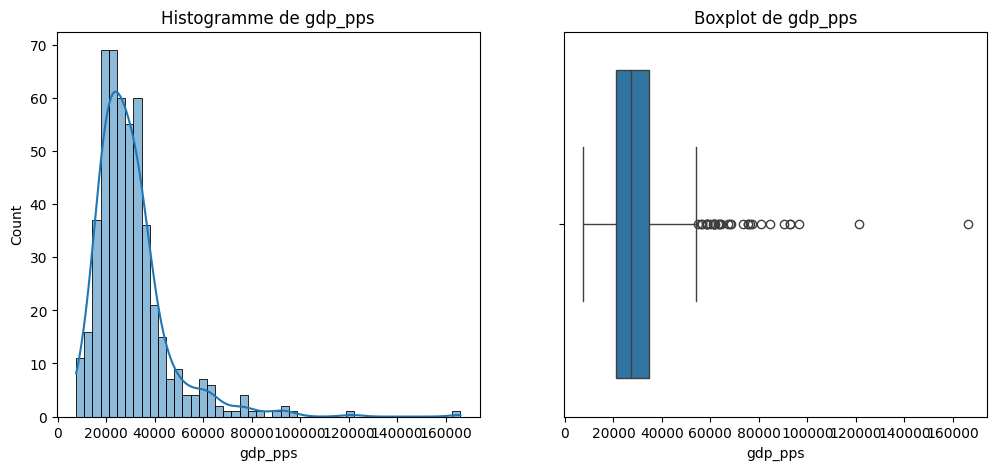

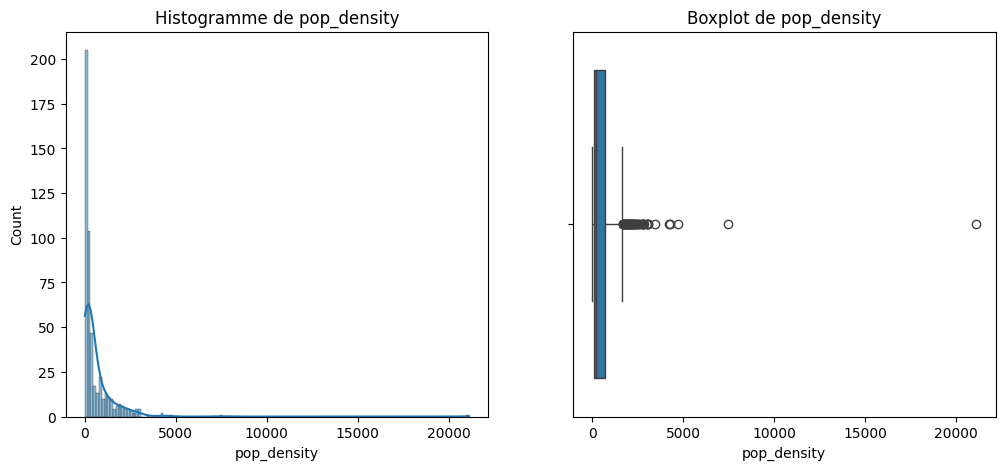

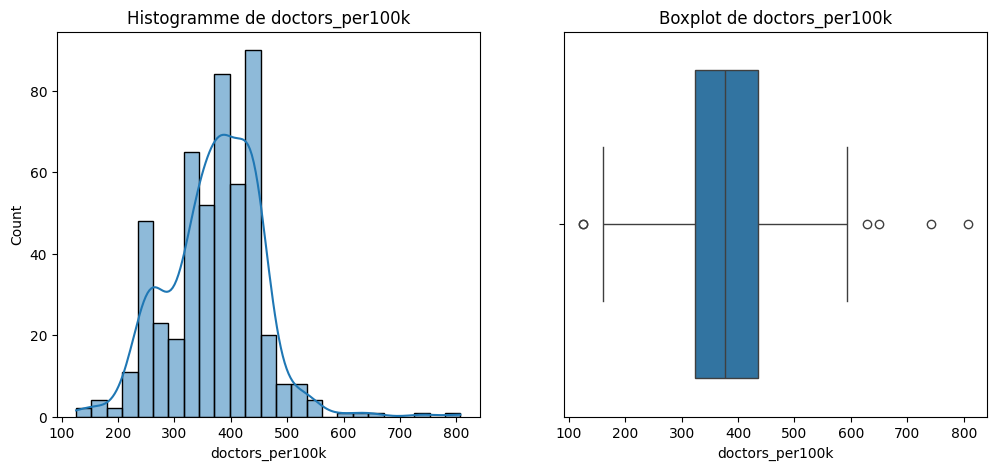

In [12]:
# 2.1 Visualization using boxplots

variables = df.columns.drop(['City_code', 'city', 'Country', 'NUTS2', 'NUTS3'])

for var in variables:
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.histplot(df[var], kde=True)
    plt.title(f"Histogramme de {var}")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[var])
    plt.title(f"Boxplot de {var}")
    plt.show()

## 3. Dealing with outliers

In [13]:
print("=== Notable extreme values — inspection before treatment ===\n")

print("POP_TOTAL > 5,000,000:")
print(df[df['pop_total'] > 5_000_000][['city', 'Country', 'pop_total']].sort_values('pop_total', ascending=False))

print("\nPOP_DENSITY > 10,000 persons/km²:")
print(df[df['pop_density'] > 10_000][['city', 'Country', 'pop_density']].sort_values('pop_density', ascending=False))

print("\nCARS_PER1000 > 1,000:")
print(df[df['cars_per1000'] > 1_000][['city', 'Country', 'cars_per1000']].sort_values('cars_per1000', ascending=False))

print("\nUNMET_MEDICAL_PCT > 10%:")
print(df[df['unmet_medical_pct'] > 10][['city', 'Country', 'unmet_medical_pct']].sort_values('unmet_medical_pct', ascending=False))

print("\nDEATHS_UNDER65_RATE > 400:")
print(df[df['deaths_under65_rate'] > 400][['city', 'Country', 'deaths_under65_rate']].sort_values('deaths_under65_rate', ascending=False))

print("\nGDP_PPS > 100,000:")
print(df[df['gdp_pps'] > 100_000][['city', 'Country', 'gdp_pps']].sort_values('gdp_pps', ascending=False))

=== Notable extreme values — inspection before treatment ===

POP_TOTAL > 5,000,000:
                     city Country    pop_total
239  Paris (greater city)      FR  10223467.25

POP_DENSITY > 10,000 persons/km²:
                     city Country  pop_density
239  Paris (greater city)      FR    21116.775

CARS_PER1000 > 1,000:
        city Country  cars_per1000
336   Trento      IT     2763.6375
353  Bolzano      IT     2230.8275

UNMET_MEDICAL_PCT > 10%:
        city Country  unmet_medical_pct
144  Tallinn      EE              14.75
145    Tartu      EE              14.75

DEATHS_UNDER65_RATE > 400:
                     city Country  deaths_under65_rate
475             Wałbrzych      PL           511.378402
21                 Pernik      BG           482.951865
315             Tatabánya      HU           440.765964
466  Piotrków Trybunalski      PL           429.165875
440                  Łódź      PL           427.447957
477             Włocławek      PL           424.295318
19   

Visual inspection of distributions identified extreme values across several variables. The treatment decision for each follows a consistent principle: **values are only corrected when they are physically or mathematically impossible, or when the data trend is clearly inconsistent with any plausible real-world explanation.** Genuine geographic and socioeconomic variation — even when extreme — is retained.

**Retained as genuine values:**

- **Paris (greater city)** — population 10.2M and density 21,117 persons/km² reflect Eurostat's greater city boundary encompassing the full Île-de-France metropolitan area. These are real values for a real metropolitan agglomeration.

- **High premature mortality** (Bulgaria, Lithuania, Poland >400 per 100,000) — well-documented structural health disadvantages in post-communist countries. Retained as the variation these values represent is precisely what the model aims to explain.

- **High unmet medical need** (Estonia 14.5%) — this variable is self-reported from the EU-SILC survey, measuring perceived unmet need due to cost, distance or waiting time. Estonia's high value reflects documented specialist waiting lists and a digitally aware population that reports access barriers more readily in surveys. Cross-country comparability is limited by cultural reporting differences but the values are not errors.

- **High GDP per capita** (Wolfsburg 163,000 PPS, Ingolstadt 120,000 PPS) — these reflect concentration of major automotive manufacturers (Volkswagen, Audi) booking large economic output against relatively small city populations. Directionally correct as economic indicators even if inflated.

- **Noise exposure variables** — apparent outliers (Saint-Étienne 25% rail night noise, A Coruña 71% road night noise) reflect genuine urban noise environments in major rail junction and port cities. END data represents actual measurements from member state submissions and values are not corrected as the measurement methodology inherently varies between countries making cross-city correction inappropriate.

- **Air quality and green space** (ISGlobal variables) — extreme values such as Ostrava PM2.5 (23 µg/m³) reflect genuine industrial pollution in the Ostrava coal basin. Values derived from validated land use regression models and retained as-is.

**Corrected as data errors:**

- **Trento and Bolzano car ownership** (2,764 and 2,231 cars per 1,000 inhabitants) — physically implausible as they imply more than 2 cars per person including children and elderly. An accelerating trend from 1,818 to 4,995 between 2015-2024 in Trento further confirms systematic reporting error, likely provincial vehicle registrations counted against city population. Both cities removed from the analysis.

In [14]:
3.1 # Fix unrealistic cars_per1000 above 2000
df = df[df['cars_per1000'] <= 2000].reset_index(drop=True)

In [15]:
# 3.2 Exporting dataset for PowerBI visualizations - after outlier removal, but before log transformation

export_df = df.copy()
export_df['city_display'] = export_df['city'].str.replace(' (greater city)', '', regex=False).str.strip()

export_df.to_excel('DATA/OUTPUT/master_2015_2019_cleaned.xlsx', index=False)
print('Exported to DATA/OUTPUT/master_2015_2019_cleaned.xlsx')

Exported to DATA/OUTPUT/master_2015_2019_cleaned.xlsx


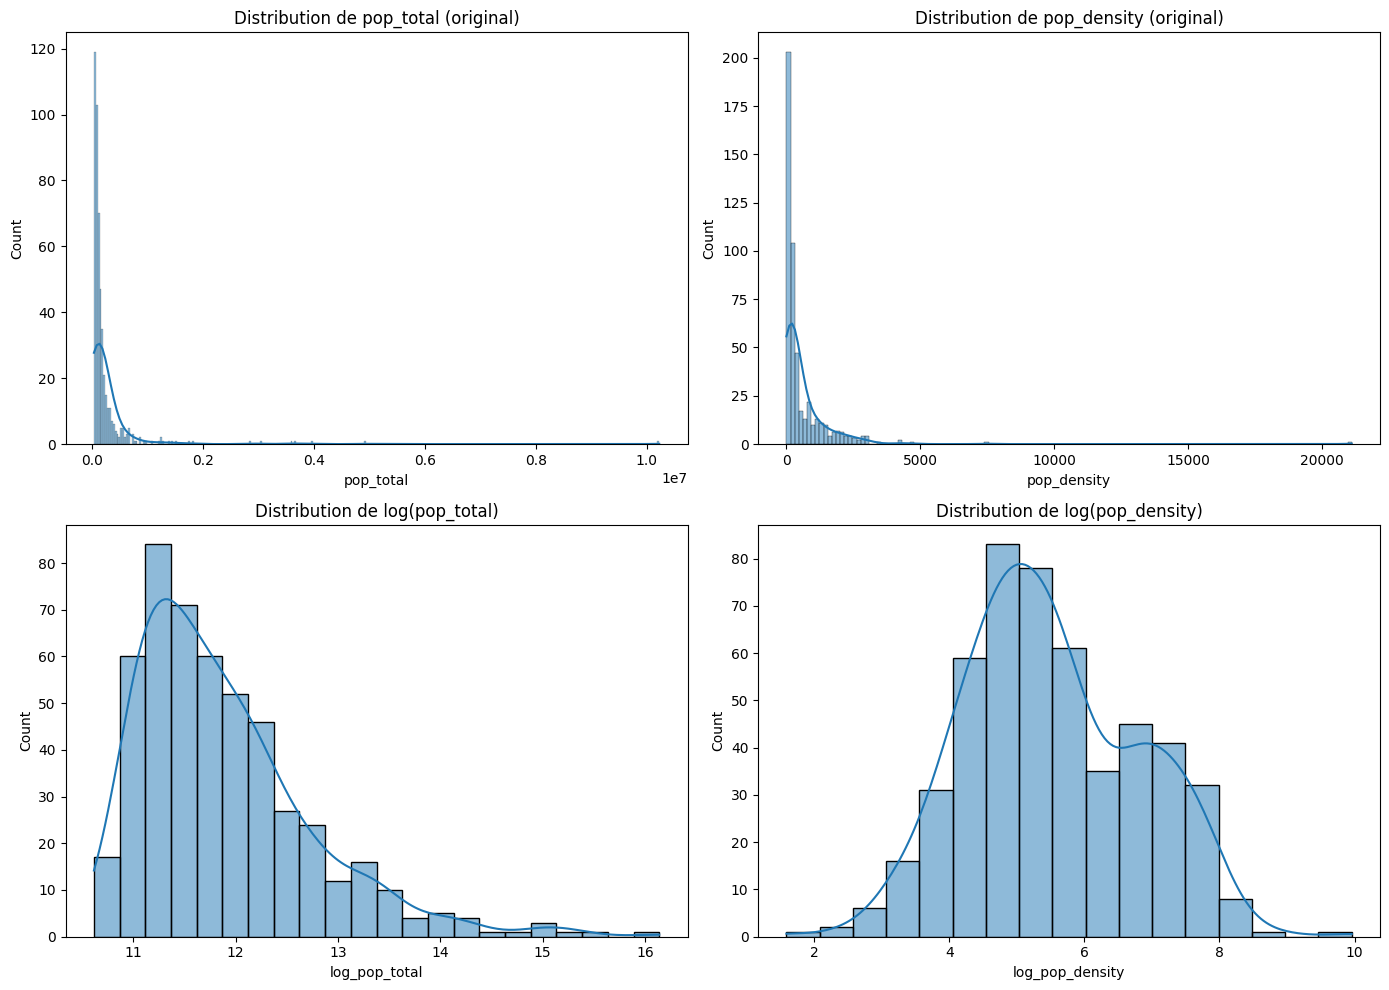

In [16]:
# 3.3 Log transformation of population metrics - total and density
# City population size and density vary inherently due to geography and administrative boundaries — 
# Paris being 70x larger than Jelgava is not a data error but a structural reality. 
# Instead of outlier removal, we apply log transformation to compress the extreme values and normalize 
# the distribution before modelling.


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['pop_total'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution de pop_total (original)')

sns.histplot(df['pop_density'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution de pop_density (original)')

df['log_pop_total'] = np.log(df['pop_total'])
df['log_pop_density'] = np.log(df['pop_density'])

sns.histplot(df['log_pop_total'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution de log(pop_total)')

sns.histplot(df['log_pop_density'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution de log(pop_density)')

plt.tight_layout()
plt.show()

df = df.drop(columns=['pop_total', 'pop_density'])

## 4. Correlation analysis

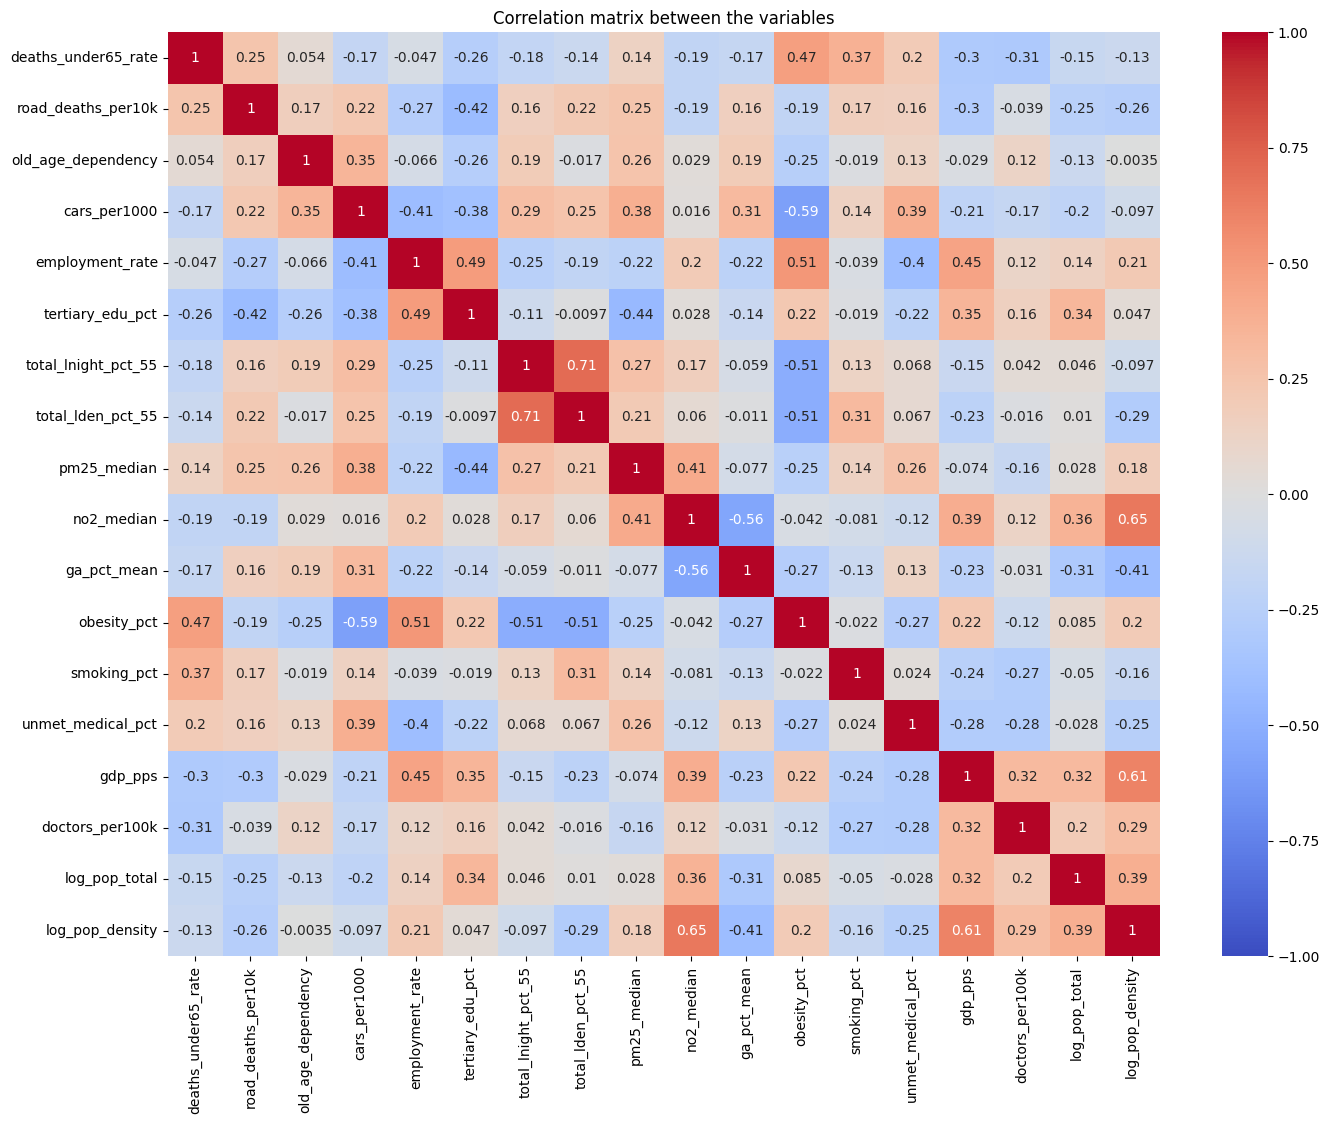


 Correlations with deaths under 65y rate:

deaths_under65_rate    1.000000
obesity_pct            0.469367
smoking_pct            0.369006
road_deaths_per10k     0.249752
unmet_medical_pct      0.197561
pm25_median            0.135194
old_age_dependency     0.054258
employment_rate       -0.047360
log_pop_density       -0.128202
total_lden_pct_55     -0.136765
log_pop_total         -0.149404
ga_pct_mean           -0.165237
cars_per1000          -0.172666
total_lnight_pct_55   -0.181215
no2_median            -0.193966
tertiary_edu_pct      -0.261985
gdp_pps               -0.297888
doctors_per100k       -0.308340
Name: deaths_under65_rate, dtype: float64


In [17]:
# 4.1 Check for multicollinearity among predictors and rank linear associations with the target (premature mortality).

df_numeric = df.select_dtypes(include='number')

plt.figure(figsize=(16,12))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix between the variables')
plt.show()

print("\n Correlations with deaths under 65y rate:\n")
print(df_numeric.corr()['deaths_under65_rate'].sort_values(ascending=False))

The strongest pairwise correlation among predictors is 0.71, below the conventional 0.8–0.9 threshold for problematic multicollinearity. No predictors were removed on collinearity grounds.

# 5. Does noise matter? 

In [18]:
# 5.1 Dropping cities without noise data
df_noise = df.dropna()
df_noise.shape

(229, 23)

In [19]:
# 5.1 Dataset separation
# Split once on the noise-subset cities so the with-noise and without-noise models are trained and 
# tested on identical city sets — making the contribution of the night-noise variables directly comparable.

# Define identifier and noise columns

id_cols = ['City_code', 'city', 'Country', 'NUTS2', 'NUTS3']
noise_cols = ['total_lden_pct_55', 'total_lnight_pct_55']

# Split indices once
train_idx, test_idx = train_test_split(df_noise.index, test_size=0.2, random_state=42)

# Target
y_train = df_noise.loc[train_idx, 'deaths_under65_rate']
y_test = df_noise.loc[test_idx, 'deaths_under65_rate']

# With noise
X_noise_train = df_noise.loc[train_idx].drop(columns=id_cols + ['deaths_under65_rate'])
X_noise_test = df_noise.loc[test_idx].drop(columns=id_cols + ['deaths_under65_rate'])

# Without noise
X_no_noise_train = df_noise.loc[train_idx].drop(columns=id_cols + noise_cols + ['deaths_under65_rate'])
X_no_noise_test = df_noise.loc[test_idx].drop(columns=id_cols + noise_cols + ['deaths_under65_rate'])

print(f'Train: {len(train_idx)} cities, Test: {len(test_idx)} cities')
print(f'With noise: {X_noise_train.shape[1]} variables')
print(f'Without noise: {X_no_noise_train.shape[1]} variables')

Train: 183 cities, Test: 46 cities
With noise: 17 variables
Without noise: 15 variables


In [20]:
# 5.2 Linear regression model on data with and without noise

# Modelisation
model_lin_noise = LinearRegression()

# Training
model_lin_noise.fit(X_noise_train, y_train)

# Model coefficients
df_coeffs_n = pd.DataFrame({
    'Variables': X_noise_train.columns,
    'Coefficients': model_lin_noise.coef_
})

print("\nLinear model coefficients - with noise:\n")
print(df_coeffs_n.sort_values(by='Coefficients', key=abs, ascending=False))

print(f'Linear WITH noise    — R² train: {model_lin_noise.score(X_noise_train, y_train):.3f}')
print(f'Linear WITH noise    — R² test:  {model_lin_noise.score(X_noise_test, y_test):.3f}')


# Modelisation
model_lin_no_noise = LinearRegression()

# Training
model_lin_no_noise.fit(X_no_noise_train, y_train)

# Model coefficients
df_coeffs_nn = pd.DataFrame({
    'Variables': X_no_noise_train.columns,
    'Coefficients': model_lin_no_noise.coef_
})

print("\nLinear model coefficients - without noise:\n")
print(df_coeffs_nn.sort_values(by='Coefficients', key=abs, ascending=False))

print(f'Linear WITHOUT noise — R² train: {model_lin_no_noise.score(X_no_noise_train, y_train):.3f}')
print(f'Linear WITHOUT noise — R² test:  {model_lin_no_noise.score(X_no_noise_test, y_test):.3f}')




Linear model coefficients - with noise:

              Variables  Coefficients
10          obesity_pct     10.053067
16      log_pop_density      8.595078
12    unmet_medical_pct      6.818310
15        log_pop_total     -5.050442
11          smoking_pct      3.794953
8            no2_median     -3.016155
7           pm25_median      2.977389
4      tertiary_edu_pct     -1.646152
9           ga_pct_mean     -1.414681
1    old_age_dependency      0.965528
0    road_deaths_per10k      0.810497
3       employment_rate     -0.737413
6     total_lden_pct_55      0.226159
5   total_lnight_pct_55     -0.195612
2          cars_per1000     -0.075794
14      doctors_per100k      0.011246
13              gdp_pps     -0.001213
Linear WITH noise    — R² train: 0.672
Linear WITH noise    — R² test:  0.688

Linear model coefficients - without noise:

             Variables  Coefficients
8          obesity_pct      9.678188
14     log_pop_density      7.700888
10   unmet_medical_pct      6.839223
13 

In [21]:
# 5.3 Random forest model on data with and without noise

# Random Forest — with noise
rf_noise = RandomForestRegressor(n_estimators=200, max_depth=6,
                                  min_samples_leaf=5, min_samples_split=10,
                                  random_state=42, n_jobs=-1)
rf_noise.fit(X_noise_train, y_train)
print(f'RF WITH noise    — R² train: {rf_noise.score(X_noise_train, y_train):.3f}')
print(f'RF WITH noise    — R² test:  {rf_noise.score(X_noise_test, y_test):.3f}')

# Random Forest — without noise
rf_no_noise = RandomForestRegressor(n_estimators=200, max_depth=6,
                                     min_samples_leaf=5, min_samples_split=10,
                                     random_state=42, n_jobs=-1)
rf_no_noise.fit(X_no_noise_train, y_train)
print(f'RF WITHOUT noise — R² train: {rf_no_noise.score(X_no_noise_train, y_train):.3f}')
print(f'RF WITHOUT noise — R² test:  {rf_no_noise.score(X_no_noise_test, y_test):.3f}')

RF WITH noise    — R² train: 0.879
RF WITH noise    — R² test:  0.849
RF WITHOUT noise — R² train: 0.870
RF WITHOUT noise — R² test:  0.832


In [22]:
# Cross-validation trains and evaluates the model on 5 different data subsets, providing a more stable R² estimate than a single train/test split.

cv_scores = cross_val_score(rf_noise, 
                             pd.concat([X_noise_train, X_noise_test]),
                             pd.concat([y_train, y_test]),
                             cv=5, scoring='r2')
print(f'Mean noise CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

cv_scores = cross_val_score(rf_no_noise, 
                             pd.concat([X_no_noise_train, X_no_noise_test]),
                             pd.concat([y_train, y_test]),
                             cv=5, scoring='r2')
print(f'Mean no noise CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

Mean noise CV R²: 0.709 ± 0.082
Mean no noise CV R²: 0.690 ± 0.082


Noise exposure adds modest predictive value in the non-linear random forest model (+0.017 R²) but not in linear regression, where confounding with urban density masks the effect. However, this marginal improvement does not justify restricting the analysis to the 230 cities with noise data — a sample that loses 270 cities. The remaining analyses therefore use the full 500-city dataset without noise variables, while acknowledging that noise is a relevant urban health determinant supported by the epidemiological literature and detected in the controlled analyses above.

## 6. Full dataset modelling - feature selection

In [23]:
# 6.1 Removing the noise columns which have missing data for 270 cities
df_full = df.drop(columns=['total_lden_pct_55', 'total_lnight_pct_55'])

df_full.shape


(500, 21)

In [24]:
# 6.2 Dataset separation

id_cols = ['City_code', 'city', 'Country', 'NUTS2', 'NUTS3']
X = df_full.drop(columns=id_cols + ['deaths_under65_rate'])
y = df_full['deaths_under65_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
# 6.3 Feature selection with RFECV

rfecv = RFECV(estimator=LinearRegression(), cv=5, scoring='r2')
rfecv.fit(X_train, y_train)
print(f'Optimal number of features: {rfecv.n_features_}')
print(f'Selected: {X_train.columns[rfecv.support_].tolist()}')

Optimal number of features: 15
Selected: ['road_deaths_per10k', 'old_age_dependency', 'cars_per1000', 'employment_rate', 'tertiary_edu_pct', 'pm25_median', 'no2_median', 'ga_pct_mean', 'obesity_pct', 'smoking_pct', 'unmet_medical_pct', 'gdp_pps', 'doctors_per100k', 'log_pop_total', 'log_pop_density']


In [26]:
# 6.4 Feature selection with Lasso

# Scale for Lasso only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_coeffs = pd.DataFrame({
    'Variable': X_train.columns,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f'Optimal alpha: {lasso.alpha_:.4f}')
print(lasso_coeffs)
print(f'\nVariables shrunk to zero: {lasso_coeffs[lasso_coeffs["Coefficient"]==0]["Variable"].tolist()}')

Optimal alpha: 0.3064
              Variable  Coefficient
8          obesity_pct    45.828062
9          smoking_pct    21.474773
10   unmet_medical_pct    14.773771
4     tertiary_edu_pct   -13.160271
2         cars_per1000   -12.991121
1   old_age_dependency    12.140121
3      employment_rate   -11.541932
11             gdp_pps    -9.771236
0   road_deaths_per10k     8.706352
5          pm25_median     6.552429
7          ga_pct_mean    -5.985753
13       log_pop_total    -5.102943
6           no2_median    -3.915855
12     doctors_per100k    -3.351844
14     log_pop_density     0.000000

Variables shrunk to zero: ['log_pop_density']


In [27]:
# 6.5 Removing log_pop_density, the only variable shrunk to zero by Lasso

selected_vars = X_train.columns.drop('log_pop_density').tolist()
print(f'Selected {len(selected_vars)} variables: {selected_vars}')

Selected 14 variables: ['road_deaths_per10k', 'old_age_dependency', 'cars_per1000', 'employment_rate', 'tertiary_edu_pct', 'pm25_median', 'no2_median', 'ga_pct_mean', 'obesity_pct', 'smoking_pct', 'unmet_medical_pct', 'gdp_pps', 'doctors_per100k', 'log_pop_total']


In [28]:
# 6.6 Filtering train and test to selected variables only
X_train_final = X_train[selected_vars]
X_test_final = X_test[selected_vars]

## 7. Full dataset modelling - Linear regression model

In [29]:
# 7.1 Setting up the model

# Modelisation
model_lin = LinearRegression()

# Training
model_lin.fit(X_train_final, y_train)

# Model coefficients
df_coeffs = pd.DataFrame({
    'Variables': selected_vars,
    'Coefficients': model_lin.coef_
})

print("\nLinear model coefficients :\n")
print(df_coeffs.sort_values(by='Coefficients', key=abs, ascending=False))

print(f'Linear  — R² train: {model_lin.score(X_train_final, y_train):.3f}')
print(f'Linear  — R² test:  {model_lin.score(X_test_final, y_test):.3f}')



Linear model coefficients :

             Variables  Coefficients
0   road_deaths_per10k     33.016723
8          obesity_pct     12.072974
10   unmet_medical_pct      9.549778
13       log_pop_total     -6.506312
9          smoking_pct      4.104333
5          pm25_median      2.276499
1   old_age_dependency      1.908931
3      employment_rate     -1.731378
4     tertiary_edu_pct     -1.347939
6           no2_median     -0.777903
7          ga_pct_mean     -0.600159
2         cars_per1000     -0.146413
12     doctors_per100k     -0.044594
11             gdp_pps     -0.000611
Linear  — R² train: 0.680
Linear  — R² test:  0.624



R2 : 0.6238
MSE : 2529.5911


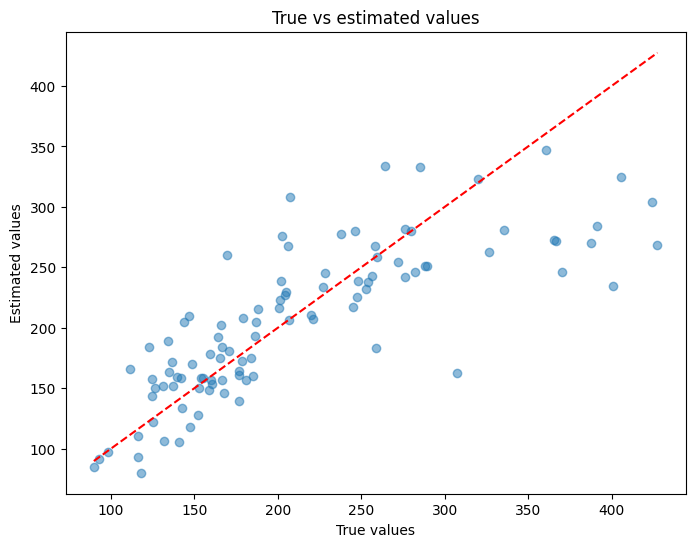

In [30]:
# 7.1 Model evaluation

# Prediction
y_pred = model_lin.predict(X_test_final)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"\nR2 : {r2:.4f}")
print(f"MSE : {mse:.4f}")

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True values")
plt.ylabel("Estimated values")
plt.title("True vs estimated values")
plt.show()


## 8. Full dataset modelling - Random forest model

In [31]:
# 8.1 Setting up the model


rf = RandomForestRegressor(n_estimators=200, max_depth=6,
                                  min_samples_leaf=5, min_samples_split=10,
                                  random_state=40, n_jobs=-1)
rf.fit(X_train_final, y_train)
print(f'RF  — R² train: {rf.score(X_train_final, y_train):.3f}')
print(f'RF  — R² test:  {rf.score(X_test_final, y_test):.3f}')


RF  — R² train: 0.889
RF  — R² test:  0.692


In [32]:
# 8.2 Cross-validation
# Cross-validation trains and evaluates the model on 5 different data subsets, providing a more stable R² estimate 
# than a single train/test split.

cv_scores_full = cross_val_score(rf, 
                                  pd.concat([X_train_final, X_test_final]),
                                  pd.concat([y_train, y_test]),
                                  cv=5, scoring='r2')
print(f'Full model CV R²: {cv_scores_full.mean():.3f} ± {cv_scores_full.std():.3f}')

Full model CV R²: 0.757 ± 0.047



R2 : 0.6924
MSE : 2068.2971


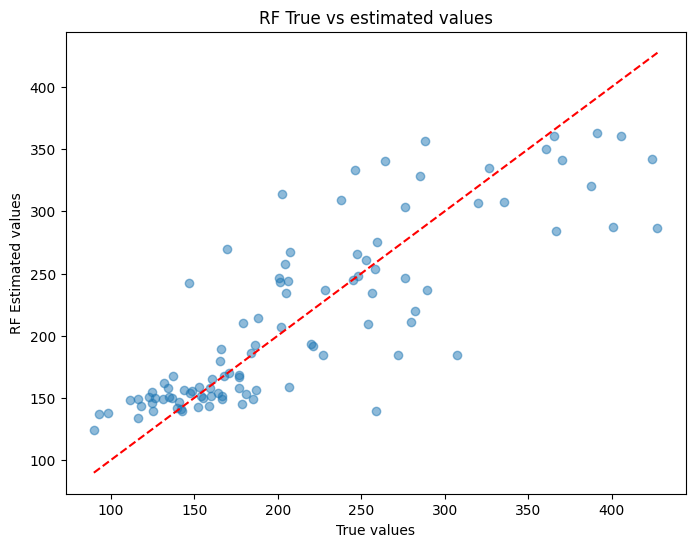

In [33]:
# 8.3 Model evaluation

# Prediction
y_pred_rf = rf.predict(X_test_final)

# Evaluation metrics
r2 = r2_score(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
print(f"\nR2 : {r2:.4f}")
print(f"MSE : {mse:.4f}")

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True values")
plt.ylabel("RF Estimated values")
plt.title("RF True vs estimated values")
plt.show()

In [34]:
# 8.4 Which cities are under or over predicted?

residuals_rf = pd.DataFrame({
    'city': df_full.loc[X_test_final.index, 'city'],
    'Country': df_full.loc[X_test_final.index, 'Country'],
    'actual': y_test,
    'predicted': y_pred_rf,
    'residual': y_test - y_pred_rf
})

print("Most under-predicted (model thinks healthier than reality):")
print(residuals_rf.nlargest(10, 'residual')[['city', 'Country', 'actual', 'predicted', 'residual']].to_string(index=False))



Most under-predicted (model thinks healthier than reality):
                     city Country     actual  predicted   residual
                     Łódź      PL 427.447957 286.617712 140.830246
                  Vilnius      LT 307.523051 184.515502 123.007549
Bratislava (greater city)      SK 258.672044 139.247497 119.424547
                 Klaipėda      LT 400.592956 287.137180 113.455776
  Budapest (greater city)      HU 272.322105 184.764126  87.557979
                Włocławek      PL 424.295318 341.809534  82.485784
                  Legnica      PL 366.558832 284.104978  82.453853
                   Žilina      SK 279.844733 210.873546  68.971188
                Panevėžys      LT 387.604010 319.957900  67.646111
                 Schwerin      DE 281.978471 220.083501  61.894970


In [35]:
print("\nMost over-predicted (model thinks sicker than reality):")
print(residuals_rf.nsmallest(10, 'residual')[['city', 'Country', 'actual', 'predicted', 'residual']].to_string(index=False))


Most over-predicted (model thinks sicker than reality):
                city Country     actual  predicted    residual
             Rzeszów      PL 202.281867 314.176317 -111.894450
Creil (greater city)      FR 169.829112 269.628371  -99.799260
       Oulu/Uleåborg      FI 146.735169 242.730462  -95.995292
               Opole      PL 246.406579 333.455326  -87.048746
            Veszprém      HU 264.380162 340.713324  -76.333162
           Nowy Sącz      PL 238.151267 309.315933  -71.164666
            Przemysl      PL 287.930253 356.354752  -68.424499
                Zlín      CZ 207.505054 267.199715  -59.694661
              Weimar      DE 204.523700 257.858744  -53.335044
           Bielefeld      DE 200.601546 246.349186  -45.747640


In [36]:
# 8.5 Exporting for PowerBI visualization the residuals
# Residuals here are in-sample fitted values on the full dataset, used for geographic visualization of relative fit

# Predict on full dataset
y_pred_all = rf.predict(df_full[selected_vars])

residuals_all = pd.DataFrame({
    'city': df_full['city'],
    'Country': df_full['Country'],
    'actual': df_full['deaths_under65_rate'],
    'predicted': y_pred_all,
    'residual': df_full['deaths_under65_rate'] - y_pred_all
})

residuals_all['abs_residual'] = residuals_all['residual'].abs()
residuals_all['prediction_quality'] = pd.cut(
    residuals_all['residual'],
    bins=[-np.inf, -50, -20, 20, 50, np.inf],
    labels=['Large over-prediction', 'Moderate over-prediction', 
            'Well predicted', 'Moderate under-prediction', 'Large under-prediction']
)


In [37]:
# Removing ' (greater city)' - present in some city names and PowerBI cannot map them then.
residuals_all['city_display'] = residuals_all['city'].str.replace(' (greater city)', '', regex=False).str.strip()


print(residuals_all['prediction_quality'].value_counts())
residuals_all.to_excel('DATA/OUTPUT/rf_residuals_all.xlsx', index=False)
print(f'Exported {len(residuals_all)} cities')

prediction_quality
Well predicted               326
Moderate over-prediction      79
Moderate under-prediction     53
Large under-prediction        27
Large over-prediction         15
Name: count, dtype: int64
Exported 500 cities


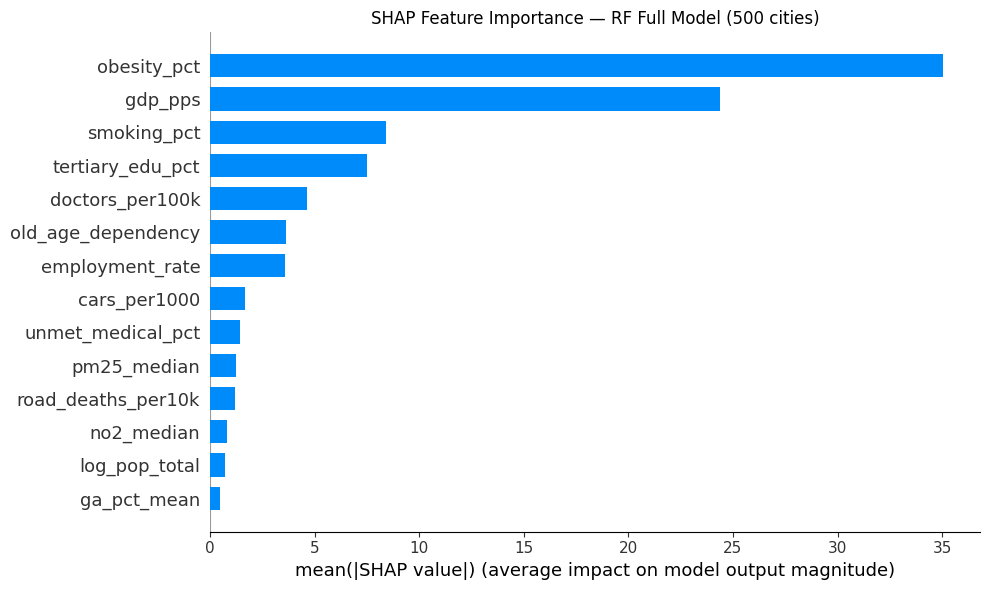

In [41]:
# 8.6 SHAP analysis

# SHAP (SHapley Additive exPlanations) quantifies each variable's contribution to individual predictions, 
# providing more reliable importance estimates than regression coefficients when predictors are correlated.

plt.close('all')
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_final)
shap.summary_plot(shap_values, X_test_final, plot_type='bar', show=False,
                  plot_size=(10, 6))
plt.title('SHAP Feature Importance — RF Full Model (500 cities)')
plt.tight_layout()
plt.show()

## 9. Do city-level levers emerge once national behavioural factors are removed?

In [42]:
# 9.1 Removing variables where we have only country level data and rerun the random forest regressor

country_only_vars = ['obesity_pct', 'smoking_pct', 'unmet_medical_pct']
city_vars = [v for v in selected_vars if v not in country_only_vars]
print(f'City-level variables ({len(city_vars)}): {city_vars}')

X_city_train = X_train[city_vars]
X_city_test = X_test[city_vars]

rf_city = RandomForestRegressor(n_estimators=200, max_depth=6,
                                 min_samples_leaf=5, min_samples_split=10,
                                 random_state=42, n_jobs=-1)
rf_city.fit(X_city_train, y_train)

print(f'RF city-level — R² train: {rf_city.score(X_city_train, y_train):.3f}')
print(f'RF city-level — R² test:  {rf_city.score(X_city_test, y_test):.3f}')

cv_scores_city = cross_val_score(rf_city,
                                  pd.concat([X_city_train, X_city_test]),
                                  pd.concat([y_train, y_test]),
                                  cv=5, scoring='r2')
print(f'CV R²: {cv_scores_city.mean():.3f} ± {cv_scores_city.std():.3f}')

City-level variables (11): ['road_deaths_per10k', 'old_age_dependency', 'cars_per1000', 'employment_rate', 'tertiary_edu_pct', 'pm25_median', 'no2_median', 'ga_pct_mean', 'gdp_pps', 'doctors_per100k', 'log_pop_total']
RF city-level — R² train: 0.790
RF city-level — R² test:  0.498
CV R²: 0.636 ± 0.077


Removing country-level behavioral variables (obesity, smoking, unmet medical need) reduces model performance by 0.116 CV R², indicating that approximately 15% of explained variance is driven by national-level factors beyond city control. The remaining 0.636 CV R² is explained by genuinely city-level variables — suggesting that cities retain meaningful independent influence on premature mortality through economic development, education, environmental quality and demographic structure.

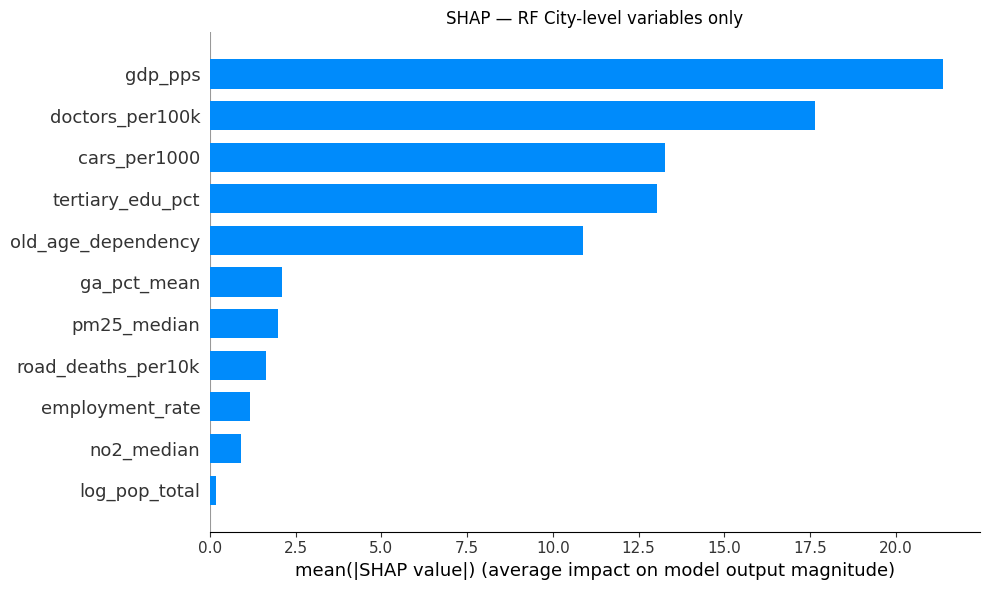

In [44]:
# 9.2 SHAP analysis

explainer_city = shap.TreeExplainer(rf_city)
shap_values_city = explainer_city.shap_values(X_city_test)

plt.close('all')
shap.summary_plot(shap_values_city, X_city_test, plot_type='bar', show=False)
plt.title('SHAP — RF City-level variables only')
plt.tight_layout()
plt.show()

**When national behavioral factors are removed, economic prosperity (gdp_pps) and healthcare capacity (doctors_per100k) emerge as the dominant city-level predictors of premature mortality. Education (tertiary_edu_pct) and urban form (cars_per1000 as proxy for car dependency) follow. Environmental variables — green space and air quality — contribute modestly but consistently. Cities seeking to reduce premature mortality should prioritize economic development, healthcare infrastructure, higher education investment and reduction of car dependency through sustainable transport.**

## 10. Validation with 2022-2024 dataset?
Out-of-time validation on 2022-2024 data was attempted but Urban Audit city-level demographic variables (old-age dependency ratio, doctors per 100,000) are not available beyond 2019 in the current data pipeline, precluding temporal validation. Future work should incorporate the Urban Audit recent data when fully published.